# Customer Cohort Retention Matrix
**Objective**: Track customer monthly retention cohorts to measure repeat purchase decay over a 12-month horizon.

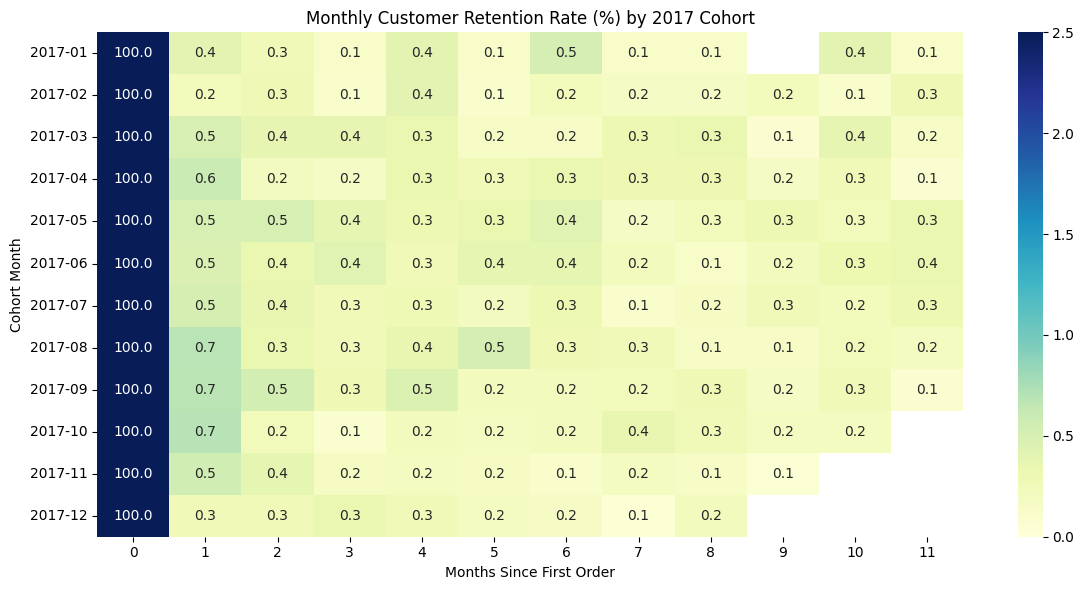

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

proc_dir = r'../data/processed'
orders = pd.read_csv(os.path.join(proc_dir, 'clean_orders.csv'))
customers = pd.read_csv(os.path.join(proc_dir, 'clean_customers.csv'))

df = orders.merge(customers[['customer_id', 'customer_unique_id']], on='customer_id')
df['order_date'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_month'] = df['order_date'].dt.to_period('M')

# First purchase month per customer
df['cohort_month'] = df.groupby('customer_unique_id')['order_month'].transform('min')

# Calculate cohort index (months elapsed)
def get_month_diff(d1, d2):
    return (d1.year - d2.year) * 12 + (d1.month - d2.month)

df['cohort_index'] = df.apply(lambda row: get_month_diff(row['order_month'], row['cohort_month']), axis=1)

# Filter to 2017 cohorts and first 12 months
cohort_data = df[df['cohort_month'].astype(str).str.startswith('2017')].groupby(['cohort_month', 'cohort_index'])['customer_unique_id'].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index='cohort_month', columns='cohort_index', values='customer_unique_id')
cohort_size = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0) * 100

plt.figure(figsize=(12, 6))
sns.heatmap(retention_matrix.iloc[:, :12], annot=True, fmt='.1f', cmap='YlGnBu', vmin=0, vmax=2.5)
plt.title('Monthly Customer Retention Rate (%) by 2017 Cohort')
plt.ylabel('Cohort Month')
plt.xlabel('Months Since First Order')
plt.tight_layout()
plt.show()